# Prediction plots: before / after `AAPredPlot`

The γ-secretase use case (and the original study scripts) hand-rolled ~95 lines of `matplotlib` / `seaborn` **glue** to draw five result figures. AAanalysis now homes these in one-call methods on `AAPredPlot` (and one extra `dPULearnPlot` parameter). Each section below shows the **before** (hand-rolled) code and figure next to the **after** (one call) — the figures are equivalent, the code collapses.

> Uses small **synthetic** inputs so the notebook runs in seconds; the point is the *plotting* code, not the analysis.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns          # 'before' only
import aaanalysis as aa
aa.options["verbose"] = False
rng = np.random.RandomState(0)

# --- synthetic inputs shared across the examples ---
# 1) an evaluation score grid (e.g. #features x JMD length -> balanced accuracy [%])
df_eval = pd.DataFrame([[63, 68, 70, 69], [66, 74, 78, 75], [67, 79, 83, 80], [68, 77, 81, 79]],
                       index=[10, 25, 50, 100], columns=[0, 5, 10, 20])
# 2) a method x condition benchmark
conds = ["No expansion", "Random", "dPULearn"]
res_scale, res_cpp = [61, 60, 63], [71, 74, 79]
# 3) per-protein prediction scores (bimodal) + a small ranking frame
scores = np.clip(np.concatenate([rng.normal(25, 15, 120), rng.normal(80, 12, 80)]), 0, 100)
df_rank = pd.DataFrame({"name": [f"P{i}" for i in range(12)],
                        "score": rng.uniform(40, 95, 12),
                        "std": rng.uniform(1, 6, 12),
                        "group": rng.choice(["Substrate", "Non-substrate"], 12)})
# 4) feature matrices for a PU-learning PCA (positives / known-neg / unlabeled)
X_pos = rng.normal(0.60, 0.15, (40, 15))
X_known = rng.normal(0.45, 0.15, (14, 15))
X_unl = rng.normal(0.42, 0.20, (200, 15))

## 1. Annotated evaluation heatmap (box the best cell)
`AAPredPlot().eval(kind="heatmap")` — square annotated grid, optimal cell boxed, grid-height colorbar.

**Before** — hand-rolled seaborn heatmap + manual best-cell box + colorbar label:

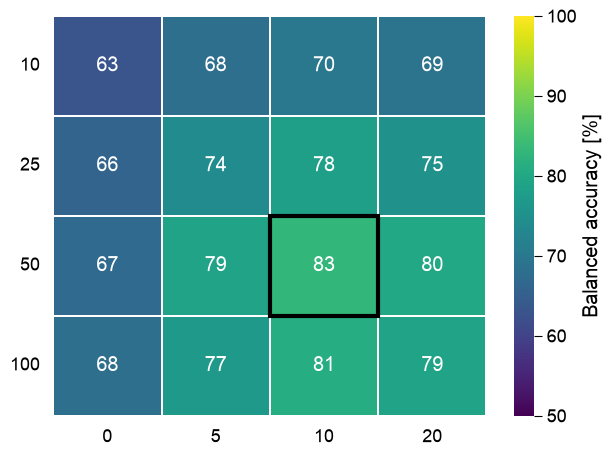

In [2]:
aa.plot_settings(weight_bold=False, font_scale=0.8)
ax = sns.heatmap(df_eval, vmin=50, vmax=100, cmap="viridis", annot=True, fmt=".0f",
                 linewidth=0.1, cbar_kws=dict(label="Balanced accuracy [%]"))
ax.tick_params(left=False, bottom=False)
plt.yticks(rotation=0); plt.xticks(rotation=0)
i, j = np.unravel_index(np.asarray(df_eval).argmax(), df_eval.shape)
ax.add_patch(plt.Rectangle((j, i), 1, 1, fill=False, edgecolor="black", lw=3))
plt.tight_layout(); plt.show()

**After** — one call (the best cell is boxed automatically):

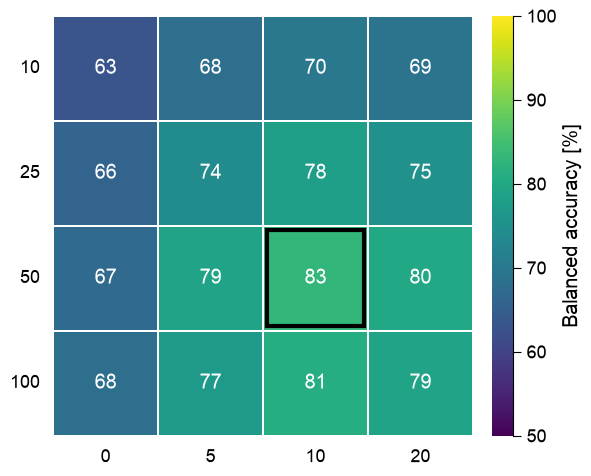

In [3]:
aa.plot_settings(weight_bold=False, font_scale=0.8)
aa.AAPredPlot().eval(df_eval, kind="heatmap", vmin=50, vmax=100,
                     cbar_label="Balanced accuracy [%]")
plt.tight_layout(); plt.show()

## 2. Grouped comparison barplot
`AAPredPlot().eval(kind="comparison")` — grouped bars with per-bar labels and a chance line.

**Before** — manual `ax.bar`, per-bar `ax.text`, `axhline`, legend:

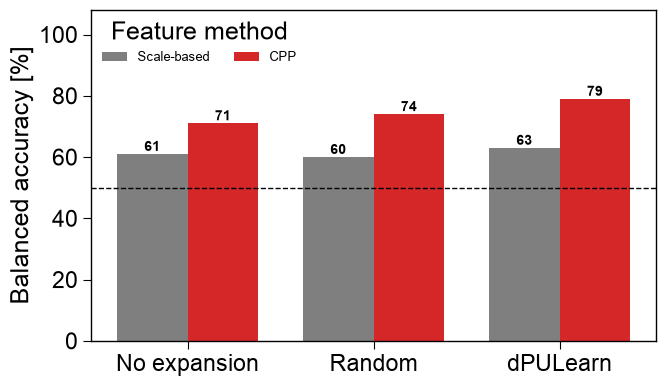

In [4]:
aa.plot_settings()
fig, ax = plt.subplots(figsize=(7, 4.2))
x = np.arange(len(conds)); w = 0.38
b1 = ax.bar(x - w / 2, res_scale, w, label="Scale-based", color="tab:gray")
b2 = ax.bar(x + w / 2, res_cpp, w, label="CPP", color="tab:red")
ax.axhline(50, ls="--", color="black", lw=1)
for bars in (b1, b2):
    for b in bars:
        ax.text(b.get_x() + b.get_width() / 2, b.get_height() + 1, f"{b.get_height():.0f}",
                ha="center", fontsize=10, weight="bold")
ax.set_xticks(x); ax.set_xticklabels(conds)
ax.set_ylabel("Balanced accuracy [%]"); ax.set_ylim(0, 108)
ax.legend(title="Feature method", loc="upper left", ncol=2, fontsize=9)
plt.tight_layout(); plt.show()

**After** — a tidy frame and one call:

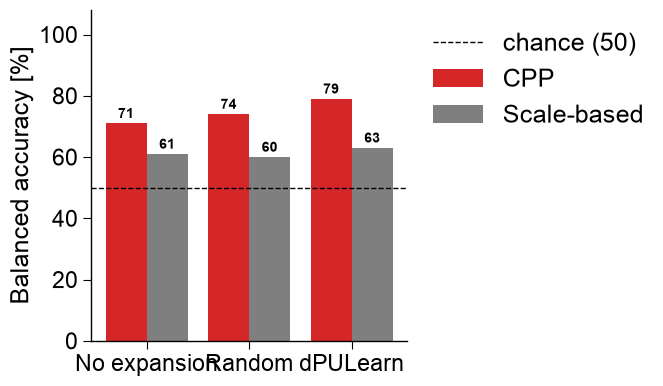

In [5]:
df_bench = pd.DataFrame({"group": np.repeat(["Scale-based", "CPP"], len(conds)),
                         "condition": conds * 2, "value": res_scale + res_cpp})
aa.plot_settings()
aa.AAPredPlot().eval(df_bench, kind="comparison", baseline=50, annotation_fmt="{:.0f}",
                     group_order=["CPP", "Scale-based"], condition_order=conds,
                     colors={"CPP": "tab:red", "Scale-based": "tab:gray"},
                     ylim=(0, 108), ylabel="Balanced accuracy [%]")
plt.tight_layout(); plt.show()

## 3. Confidence-banded score histogram
`AAPredPlot().predict_group(kind="hist", band=True)` — bars colored by the confidence band they fall into (no class labels needed).

**Before** — manual `ax.hist`, then recolor each patch by its band:

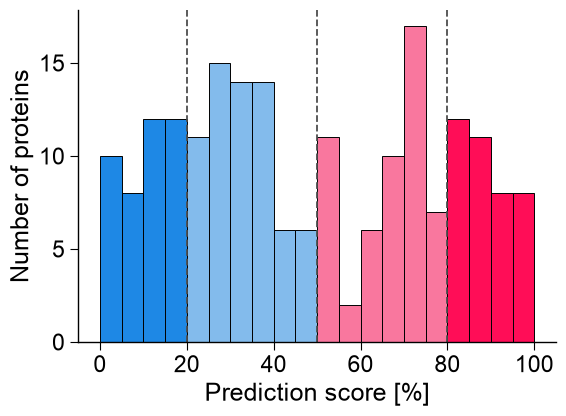

In [6]:
BANDS = [(80, "#FF0D57"), (50, "#F9779E"), (20, "#83BBEC"), (0, "#1E88E5")]
aa.plot_settings()
fig, ax = plt.subplots(figsize=(6, 4.5))
_, edges, patches = ax.hist(scores, bins=np.arange(0, 101, 5), edgecolor="black", linewidth=0.7)
for p, left in zip(patches, edges[:-1]):
    p.set_facecolor(next(c for t, c in BANDS if left >= t))
for t in (20, 50, 80):
    ax.axvline(t, ls="--", color="0.3", lw=1.3)
ax.set_xlabel("Prediction score [%]"); ax.set_ylabel("Number of proteins"); sns.despine()
plt.tight_layout(); plt.show()

**After** — one call; `thresholds` delimit the bands, `colors` are low->high:

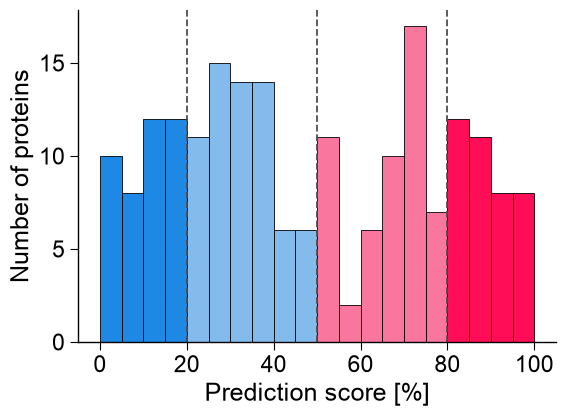

In [7]:
aa.plot_settings()
aa.AAPredPlot().predict_group(scores, kind="hist", band=True, thresholds=[20, 50, 80],
                              colors=["#1E88E5", "#83BBEC", "#F9779E", "#FF0D57"],
                              xlabel="Prediction score [%]", ylabel="Number of proteins")
plt.tight_layout(); plt.show()

## 4. Ranked candidates with error bars
`AAPredPlot().predict_group(kind="ranking")` — horizontal bars by score, class-colored, with error bars and confidence cut-offs.

**Before** — sort, `ax.barh`, `ax.errorbar`, per-class colors, cut-off lines:

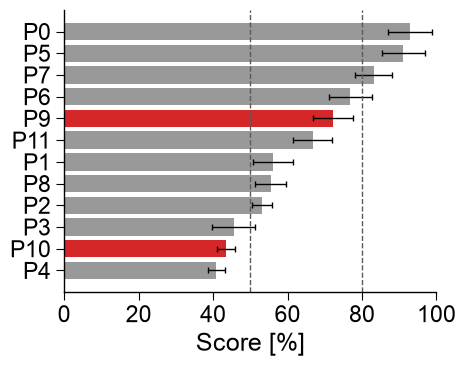

In [8]:
d = df_rank.sort_values("score").reset_index(drop=True)
cmap = {"Substrate": "tab:red", "Non-substrate": "0.6"}
aa.plot_settings()
fig, ax = plt.subplots(figsize=(5, 4))
ax.barh(range(len(d)), d["score"], color=[cmap[g] for g in d["group"]], height=0.8)
ax.errorbar(y=range(len(d)), x=d["score"], xerr=d["std"], fmt="none", ecolor="k",
            elinewidth=1, capsize=2)
ax.set_yticks(range(len(d))); ax.set_yticklabels(d["name"])
for c in (50, 80):
    ax.axvline(c, ls="--", color="0.35", lw=1)
ax.set_xlim(0, 100); ax.set_xlabel("Score [%]"); sns.despine()
plt.tight_layout(); plt.show()

**After** — one call, columns referenced by name:

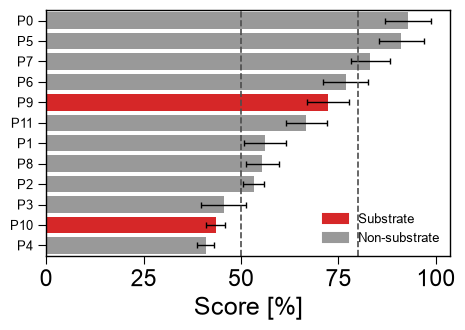

In [9]:
aa.plot_settings()
aa.AAPredPlot().predict_group(df_rank, kind="ranking", col_name="name", col_score="score",
                              col_std="std", col_group="group",
                              colors={"Substrate": "tab:red", "Non-substrate": "0.6"},
                              cutoffs=(50, 80), xlabel="Score [%]")
plt.tight_layout(); plt.show()

## 5. PU-learning PCA with a projected 4th group
`dPULearn.project(X)` + `dPULearnPlot().pca(df_pu_add=...)` — overlay held-out samples (here the known negatives) in the fitted PC space.

**Before** — reconstruct the affine PC map by least squares and scatter four groups by hand:

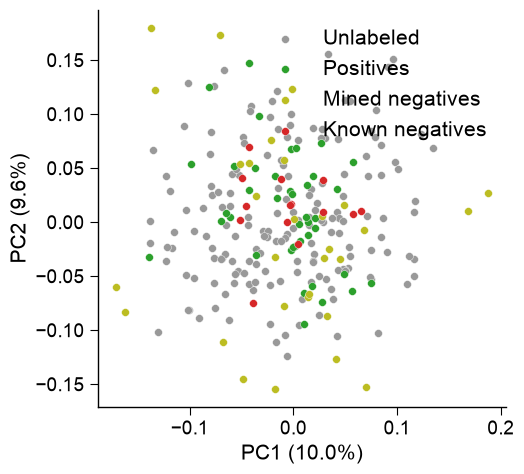

In [10]:
dpul = aa.dPULearn(random_state=0)
dpul.fit(X=np.vstack([X_pos, X_unl]),
         labels=np.array([1] * len(X_pos) + [2] * len(X_unl)), n_unl_to_neg=30)
pcs = ([c for c in dpul.df_pu_.columns if c.startswith("PC1")][:1]
       + [c for c in dpul.df_pu_.columns if c.startswith("PC2")][:1])
Z = dpul.df_pu_[pcs].to_numpy(); lab = np.asarray(dpul.labels_)
X_pool = np.vstack([X_pos, X_unl])
W, *_ = np.linalg.lstsq(np.hstack([X_pool, np.ones((len(X_pool), 1))]), Z, rcond=None)
Z_known = np.hstack([X_known, np.ones((len(X_known), 1))]) @ W
aa.plot_settings(font_scale=0.85)
fig, ax = plt.subplots(figsize=(5.5, 5))
for Zg, col, name in [(Z[lab == 2], "0.6", "Unlabeled"), (Z[lab == 1], "tab:green", "Positives"),
                      (Z[lab == 0], "tab:olive", "Mined negatives"), (Z_known, "tab:red", "Known negatives")]:
    ax.scatter(Zg[:, 0], Zg[:, 1], color=col, s=32, edgecolors="white", linewidths=0.3, label=name)
ax.set_xlabel(pcs[0]); ax.set_ylabel(pcs[1]); ax.legend(frameon=False); sns.despine()
plt.tight_layout(); plt.show()

**After** — project the extra group and overlay it in one call:

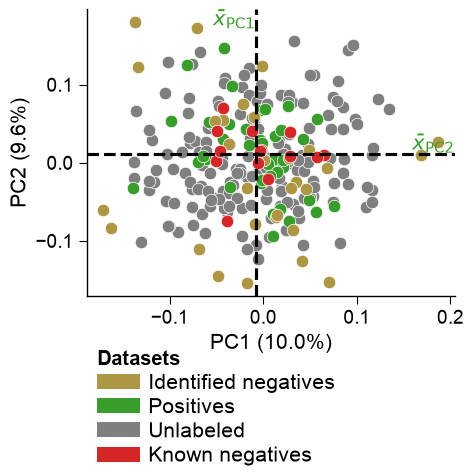

In [11]:
df_pu_known = dpul.project(X_known)
aa.plot_settings(font_scale=0.85)
aa.dPULearnPlot().pca(df_pu=dpul.df_pu_, labels=np.asarray(dpul.labels_),
                      df_pu_add=df_pu_known, names_add="Known negatives", colors_add="tab:red")
plt.tight_layout(); plt.show()

## Lines of user code: before vs after

In [12]:
pairs = {
    "eval heatmap": (8, 3), "comparison bars": (13, 6), "banded histogram": (9, 4),
    "ranking": (11, 4), "PU-PCA (4 groups)": (15, 4),
}
df_loc = pd.DataFrame([(k, b, a, f"-{round(100 * (b - a) / b)}%") for k, (b, a) in pairs.items()],
                      columns=["figure", "before (lines)", "after (lines)", "reduction"])
tot_b, tot_a = df_loc["before (lines)"].sum(), df_loc["after (lines)"].sum()
print(f"total: {tot_b} -> {tot_a} lines of plotting code ({round(100 * (tot_b - tot_a) / tot_b)}% fewer)")
aa.display_df(df_loc, n_rows=10, show_shape=False)

total: 56 -> 21 lines of plotting code (62% fewer)


,figure,before (lines),after (lines),reduction
1,eval heatmap,8,3,-62%
2,comparison bars,13,6,-54%
3,banded histogram,9,4,-56%
4,ranking,11,4,-64%
5,PU-PCA (4 groups),15,4,-73%
